# EDA MIT-BIH (MIT-Arrhythmia): señales ECG, clases AAMI y diagnóstico de ruido

Objetivos de este notebook:

- Visualizar segmentos ECG con anotaciones.
- Entender la distribución de símbolos MIT-BIH y su mapeo a clases AAMI.
- Identificar posibles fuentes de ruido/artefactos.
- Comparar morfología **N vs SVEB vs VEB** usando ventanas centradas en R-peak.
- Analizar registros potencialmente “problemáticos”: **108, 207, 217**.

**Decisiones alineadas a la arquitectura/pipeline de la tesis**

- Dataset: MIT-BIH Arrhythmia Database (fs = 360 Hz).
- Segmentación beat-level: **ventanas de 250 muestras**, centradas en R-peak.
- Clases AAMI 3-clase para L1: `0=N`, `1=SVEB`, `2=VEB`.
- Latidos/segmentos no-clasificables se consideran **Q/ruido** (se excluyen del entrenamiento L1, pero son útiles para EDA de calidad).

> Nota sobre WFDB: en este proyecto se usa `wfdb==4.3.x`; la lectura local suele ser más robusta si ejecutamos las funciones desde el directorio `data/raw/mitdb` (ver helpers).

In [1]:
# Imports y configuración base
from __future__ import annotations

import json
import os
from contextlib import contextmanager
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb

# ---------------------------
# Paths del proyecto
# ---------------------------
PROJECT_ROOT = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "mitdb"
INDEX_CSV = PROJECT_ROOT / "reports" / "metadata" / "mitbih_index.csv"
EDA_DIR = PROJECT_ROOT / "reports" / "eda"
FIG_DIR = EDA_DIR / "figures"
TABLE_DIR = EDA_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Reproducibilidad
# ---------------------------
SEED = 42
rng = np.random.default_rng(SEED)

# ---------------------------
# Estilo plots
# ---------------------------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("INDEX_CSV:", INDEX_CSV)
print("EDA_DIR:", EDA_DIR)

assert INDEX_CSV.exists(), f"No existe {INDEX_CSV}. Genera el index primero (scripts/index_mitbih.py)."
assert DATA_DIR.exists(), f"No existe {DATA_DIR}. Descarga mitdb primero (scripts/download_mitbih.py)."


def save_fig(fig: plt.Figure, name: str, dpi: int = 150) -> None:
    out_png = FIG_DIR / f"{name}.png"
    out_svg = FIG_DIR / f"{name}.svg"
    fig.tight_layout()
    fig.savefig(out_png, dpi=dpi)
    fig.savefig(out_svg)
    print("Saved:", out_png)


def save_table(df: pd.DataFrame, name: str) -> None:
    out_csv = TABLE_DIR / f"{name}.csv"
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)


@contextmanager
def chdir(path: Path):
    """Context manager para ejecutar WFDB desde un directorio local (más robusto en wfdb 4.3.x)."""
    prev = Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(prev)


PROJECT_ROOT: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis
DATA_DIR: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/data/raw/mitdb
INDEX_CSV: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/metadata/mitbih_index.csv
EDA_DIR: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda


## 1) Cargar `mitbih_index.csv` y validar esquema

Leemos el índice generado en `reports/metadata/mitbih_index.csv` y validamos:

- Columnas esperadas: `record_id, fs, sig_len, n_annotations, symbol_counts_json`.
- Tipos razonables (`record_id` como string/categórico, `fs`/`sig_len` int).
- `symbol_counts_json` sin `NaN`.
- Checks globales: `fs==360`, `sig_len==650000` para MIT-BIH (debería cumplirse para todos los registros estándar).

In [4]:
df_index = pd.read_csv(INDEX_CSV)

expected_cols = {"record_id", "fs", "sig_len", "n_annotations", "symbol_counts_json"}
missing = expected_cols - set(df_index.columns)
assert not missing, f"Faltan columnas: {missing}"

# Normalizar tipo record_id (como string, preserva ceros si existieran)
df_index["record_id"] = df_index["record_id"].astype(str)

# Checks básicos
assert df_index["symbol_counts_json"].notna().all(), "Hay nulos en symbol_counts_json"

print("n_records:", len(df_index))
print("columns:", list(df_index.columns))

display(df_index.head())
display(df_index.describe(include="all"))

# Checks esperados para MIT-BIH
bad_fs = df_index.loc[df_index["fs"] != 360, ["record_id", "fs"]]
bad_len = df_index.loc[df_index["sig_len"] != 650000, ["record_id", "sig_len"]]

print("Bad fs rows:", len(bad_fs))
print("Bad sig_len rows:", len(bad_len))

if len(bad_fs):
    display(bad_fs)
if len(bad_len):
    display(bad_len)

assert len(bad_fs) == 0, "Se encontraron registros con fs != 360"
assert len(bad_len) == 0, "Se encontraron registros con sig_len != 650000"


n_records: 48
columns: ['record_id', 'fs', 'sig_len', 'n_annotations', 'symbol_counts_json']


,record_id,fs,sig_len,n_annotations,symbol_counts_json
0,100,360,650000,2274,"{""+"": 1, ""N"": 2239, ""A"": 33, ""V"": 1}"
1,101,360,650000,1874,"{""+"": 1, ""N"": 1860, ""~"": 4, ""|"": 4, ""Q"": 2, ""A..."
2,102,360,650000,2192,"{""+"": 5, ""/"": 2028, ""f"": 56, ""N"": 99, ""V"": 4}"
3,103,360,650000,2091,"{""+"": 1, ""N"": 2082, ""~"": 6, ""A"": 2}"
4,104,360,650000,2311,"{""+"": 45, ""/"": 1380, ""f"": 666, ""~"": 37, ""Q"": 1..."


,record_id,fs,sig_len,n_annotations,symbol_counts_json
count,48,48.0,48.0,48.000000,48
unique,48,NaN,NaN,NaN,48
top,100,NaN,NaN,NaN,"{""+"": 1, ""N"": 2239, ""A"": 33, ""V"": 1}"
freq,1,NaN,NaN,NaN,1
mean,NaN,360.0,650000.0,2346.812500,NaN
std,NaN,0.0,0.0,451.689107,NaN
min,NaN,360.0,650000.0,1519.000000,NaN
25%,NaN,360.0,650000.0,2061.500000,NaN
50%,NaN,360.0,650000.0,2299.000000,NaN
75%,NaN,360.0,650000.0,2650.250000,NaN


Bad fs rows: 0
Bad sig_len rows: 0


## 2) Parsear `symbol_counts_json` a columnas y tabla “long”

Convertimos `symbol_counts_json` → `dict` → columnas por símbolo (fillna=0) y además una tabla larga:

- `df_symbols_wide`: una columna por símbolo.
- `df_symbols_long`: (record_id, symbol, count).

Validación: `sum(counts)` debería ser cercano a `n_annotations` (pueden existir discrepancias pequeñas si el indexado filtró algo; aquí las detectamos).

In [5]:
def parse_symbol_counts(s: str) -> Dict[str, int]:
    d = json.loads(s)
    # garantizar ints
    return {str(k): int(v) for k, v in d.items()}


symbol_dicts = df_index["symbol_counts_json"].apply(parse_symbol_counts)

# Wide
all_symbols = sorted({sym for d in symbol_dicts for sym in d.keys()})

df_symbols_wide = pd.DataFrame([
    {"record_id": rid, **{sym: d.get(sym, 0) for sym in all_symbols}}
    for rid, d in zip(df_index["record_id"], symbol_dicts)
])

# Long
rows = []
for rid, d in zip(df_index["record_id"], symbol_dicts):
    for sym, cnt in d.items():
        rows.append({"record_id": rid, "symbol": sym, "count": int(cnt)})

df_symbols_long = pd.DataFrame(rows).sort_values(["record_id", "symbol"]).reset_index(drop=True)

# Validación de suma
sum_counts = df_symbols_wide[all_symbols].sum(axis=1)
check = df_index[["record_id", "n_annotations"]].copy()
check["sum_symbol_counts"] = sum_counts.values
check["diff"] = check["n_annotations"] - check["sum_symbol_counts"]

print("Max |diff|:", check["diff"].abs().max())

display(df_symbols_wide.head())
display(df_symbols_long.head(15))

discrep = check.loc[check["diff"].abs() > 0]
print("Records con discrepancia:", len(discrep))
if len(discrep):
    display(discrep.sort_values("diff"))

save_table(check.sort_values("diff"), "index_symbol_sum_check")


Max |diff|: 0


,record_id,!,"""",+,/,A,E,F,J,L,...,V,[,],a,e,f,j,x,|,~
0,100,0,0,1,0,33,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,101,0,0,1,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,4,4
2,102,0,0,5,2028,0,0,0,0,0,...,4,0,0,0,0,56,0,0,0,0
3,103,0,0,1,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
4,104,0,0,45,1380,0,0,0,0,0,...,2,0,0,0,0,666,0,0,0,37


,record_id,symbol,count
0,100,+,1
1,100,A,33
2,100,N,2239
3,100,V,1
4,101,+,1
5,101,A,3
6,101,N,1860
7,101,Q,2
8,101,|,4
9,101,~,4


Records con discrepancia: 0
Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/tables/index_symbol_sum_check.csv


## 3) Mapeo de símbolos MIT-BIH → clases AAMI (N, SVEB, VEB, F, Q)

Usaremos el mapeo en `src/data/aami_mapping.py` (si está disponible/importable) para consistencia con el pipeline.

Para EDA, añadimos dos clases auxiliares:

- **F**: fusión ventricular (`F`).
- **Q**: no-clasificable/ruido/otros (incluye artefactos y marcas de ritmo).

> Para L1 del prototipo (3-clase), normalmente entrenarás sólo N/SVEB/VEB y tratarás el resto como “other/Q”. Aquí lo incluimos para cuantificar calidad y ruido.

In [6]:
# Intentar usar el mapeo del proyecto
try:
    from src.data.aami_mapping import (
        N_SYMBOLS,
        SVEB_SYMBOLS,
        VEB_SYMBOLS,
        map_symbol_to_aami_class,
    )
    print("Usando src.data.aami_mapping")
except Exception as e:
    print("No se pudo importar src.data.aami_mapping; usando fallback local. Error:", repr(e))

    # Fallback razonable para EDA (documentado)
    # - N: normales y variantes supraventriculares normales
    # - SVEB: supraventricular ectópico
    # - VEB: ventricular ectópico
    # - F: fusion ventricular
    # - Q: resto (ruido/artefactos/marcas)
    N_SYMBOLS = {"N", "L", "R", "e", "j"}
    SVEB_SYMBOLS = {"A", "a", "J", "S"}
    VEB_SYMBOLS = {"V", "E"}

    def map_symbol_to_aami_class(symbol: str) -> int | None:
        if symbol in N_SYMBOLS:
            return 0
        if symbol in SVEB_SYMBOLS:
            return 1
        if symbol in VEB_SYMBOLS:
            return 2
        return None


AAMI_ID_TO_NAME = {
    0: "N",
    1: "SVEB",
    2: "VEB",
    3: "F",
    4: "Q",
}


def map_symbol_to_aami_5(symbol: str) -> int:
    """AAMI extendida para EDA: N, SVEB, VEB, F, Q."""
    if symbol == "F":
        return 3
    cls3 = map_symbol_to_aami_class(symbol)
    if cls3 is None:
        return 4
    return int(cls3)


df_symbols_long["aami_5"] = df_symbols_long["symbol"].apply(map_symbol_to_aami_5)
df_symbols_long["aami_name"] = df_symbols_long["aami_5"].map(AAMI_ID_TO_NAME)

unknown_symbols = (
    df_symbols_long.loc[df_symbols_long["aami_5"] == 4]
    .groupby("symbol", as_index=False)["count"].sum()
    .sort_values("count", ascending=False)
)

print("Top símbolos en Q/other:")
display(unknown_symbols.head(20))

save_table(unknown_symbols, "unknown_symbols_total")


Usando src.data.aami_mapping
Top símbolos en Q/other:


,symbol,count
2,+,1291
8,~,616
0,!,472
1,"""",437
6,x,193
7,|,132
3,Q,33
4,[,6
5,],6


Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/tables/unknown_symbols_total.csv


## 4) Distribución de clases por registro (AAMI) y ranking de desbalance

A partir del mapeo extendido (N/SVEB/VEB/F/Q):

- Tabla por registro: conteos y porcentajes.
- Barras apiladas para top-N registros.
- Heatmap registros × clases.
- Ranking por %Q (proxy de ruido/no-clasificable) y por desbalance (por ejemplo entropía).

Top registros por %Q:


,record_id,cnt_N,cnt_SVEB,cnt_VEB,cnt_F,cnt_Q,pct_Q,entropy,total
28,207,1543,107,210,0,525,22.012579,1.396697,2385
44,231,1568,1,2,0,440,21.879662,0.774959,2011
43,230,2255,0,1,0,210,8.515815,0.425201,2466
23,200,1743,30,826,2,191,6.840974,1.286647,2792
37,219,2082,7,64,1,158,6.833910,0.574102,2312
40,222,2274,209,0,0,151,5.732726,0.709566,2634
18,119,1543,0,444,0,107,5.109838,1.018303,2094
5,105,2526,0,41,0,124,4.607952,0.382241,2691
4,104,2209,0,2,0,100,4.327131,0.267093,2311
26,203,2529,2,444,1,132,4.247104,0.847175,3108


Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/tables/aami_per_record_summary.csv
Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/aami_stacked_bar_topN.png


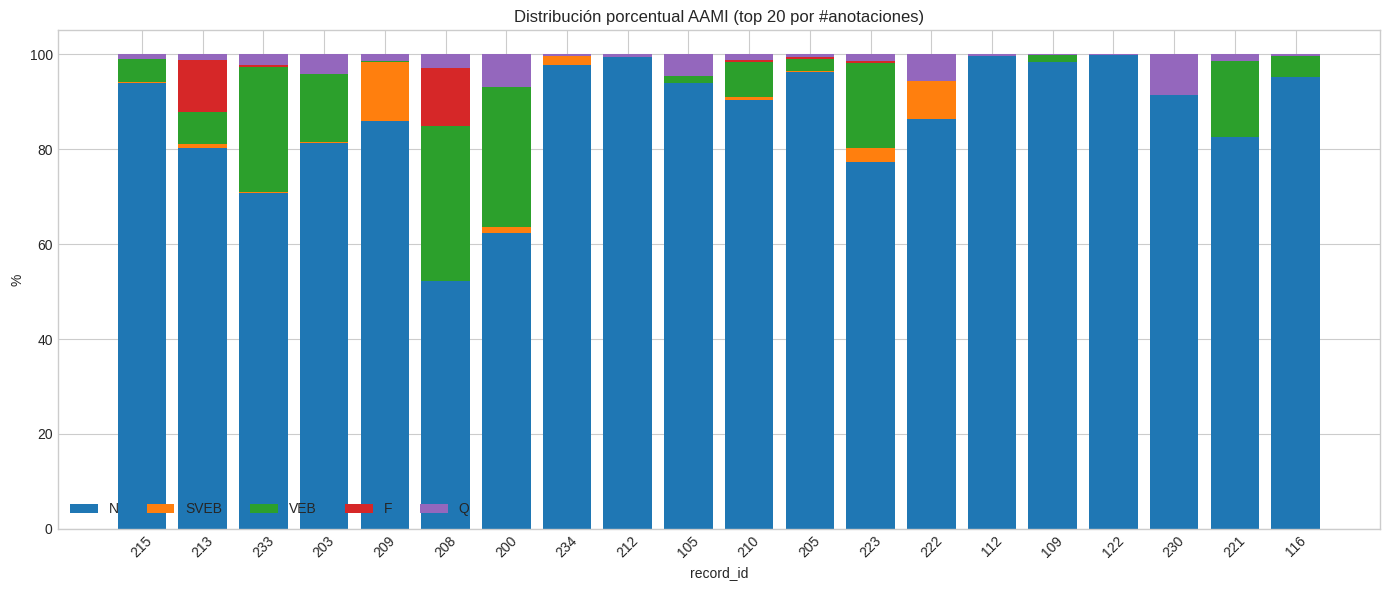

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/aami_heatmap_pct_all.png


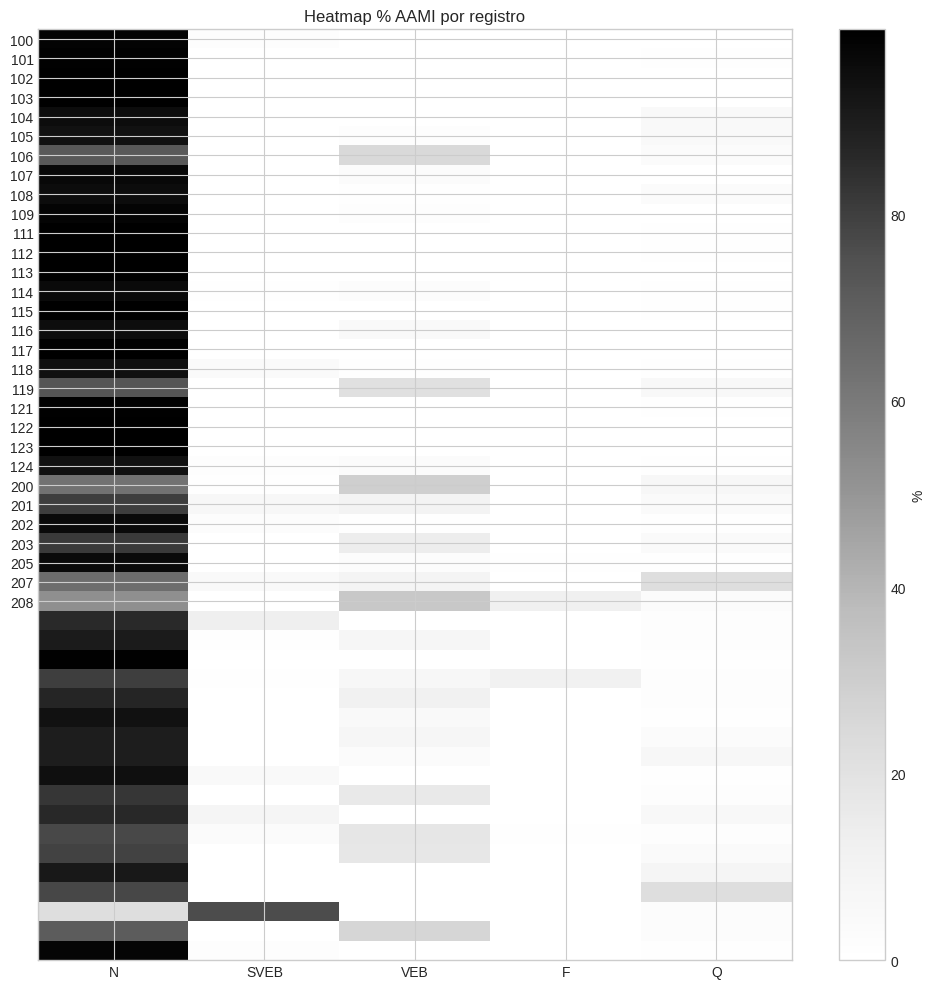

In [7]:
df_aami = (
    df_symbols_long.groupby(["record_id", "aami_name"], as_index=False)["count"].sum()
)

df_aami_pivot = df_aami.pivot(index="record_id", columns="aami_name", values="count").fillna(0).astype(int)
for col in ["N", "SVEB", "VEB", "F", "Q"]:
    if col not in df_aami_pivot.columns:
        df_aami_pivot[col] = 0

# Orden fijo columnas
class_cols = ["N", "SVEB", "VEB", "F", "Q"]
df_aami_pivot = df_aami_pivot[class_cols]

# % por registro
row_sum = df_aami_pivot.sum(axis=1).replace({0: np.nan})
df_aami_pct = (df_aami_pivot.div(row_sum, axis=0) * 100.0).fillna(0.0)

# Entropía (desbalance): más alta = más balanceado
p = (df_aami_pivot.div(df_aami_pivot.sum(axis=1).replace({0: np.nan}), axis=0)).fillna(0.0)
entropy = -(p * np.log2(p.replace({0.0: np.nan}))).sum(axis=1).fillna(0.0)

summary = df_aami_pivot.copy()
summary.columns = [f"cnt_{c}" for c in summary.columns]
summary["pct_Q"] = df_aami_pct["Q"]
summary["entropy"] = entropy
summary["total"] = df_aami_pivot.sum(axis=1)
summary = summary.reset_index()

# Ranking de ruido/no-clasificable
summary_q = summary.sort_values(["pct_Q", "total"], ascending=[False, False])

print("Top registros por %Q:")
display(summary_q.head(10))
save_table(summary_q, "aami_per_record_summary")

# Barras apiladas para top-N por total
TOPN = 20
top_records = (
    summary.sort_values("total", ascending=False)
    .head(TOPN)["record_id"].tolist()
)

df_plot = df_aami_pct.loc[top_records, class_cols]

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(df_plot))
for c in class_cols:
    ax.bar(df_plot.index, df_plot[c].values, bottom=bottom, label=c)
    bottom += df_plot[c].values

ax.set_title(f"Distribución porcentual AAMI (top {TOPN} por #anotaciones)")
ax.set_ylabel("%")
ax.set_xlabel("record_id")
ax.legend(ncol=5)
plt.xticks(rotation=45)
save_fig(fig, "aami_stacked_bar_topN")
plt.show()

# Heatmap simple (matplotlib)
fig, ax = plt.subplots(figsize=(10, 10))
mat = df_aami_pct[class_cols].values
im = ax.imshow(mat, aspect="auto", interpolation="nearest")
ax.set_yticks(np.arange(len(df_aami_pct.index)))
ax.set_yticklabels(df_aami_pct.index)
ax.set_xticks(np.arange(len(class_cols)))
ax.set_xticklabels(class_cols)
ax.set_title("Heatmap % AAMI por registro")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("%")

# Para no saturar, mostramos sólo primeros 30 registros en y-label
ax.set_yticks(np.arange(min(30, len(df_aami_pct.index))))
ax.set_yticklabels(df_aami_pct.index[:30])

save_fig(fig, "aami_heatmap_pct_all")
plt.show()


## 5) Seleccionar registros y utilidades de carga de señal/anotaciones (WFDB)

Implementamos helpers:

- `load_record(record_id, sampfrom, sampto, channels)` → señal y `fs`.
- `load_annotations(record_id)` → muestras de anotación y símbolos.

**Nota**: leeremos desde `data/raw/mitdb` con un `chdir(DATA_DIR)` para evitar problemas de rutas en `wfdb==4.3.x`.

In [11]:
@dataclass
class Annotations:
    sample: np.ndarray  # indices de muestra
    symbol: List[str]


def load_record(
    record_id: str,
    sampfrom: int | None = None,
    sampto: int | None = None,
    channels: Optional[List[int]] = None,
) -> Tuple[np.ndarray, int]:
    """Carga señal (record.p_signal) como numpy array shape (n, n_channels).

    Nota: en `wfdb`, `sampfrom`/`sampto` deben ser enteros si se pasan.
    Si son `None`, NO deben incluirse en la llamada (evita TypeError).
    """
    record_id = str(record_id)

    kwargs = {}
    if sampfrom is not None:
        kwargs["sampfrom"] = int(sampfrom)
    if sampto is not None:
        kwargs["sampto"] = int(sampto)
    if channels is not None:
        kwargs["channels"] = list(channels)

    with chdir(DATA_DIR):
        rec = wfdb.rdrecord(record_id, **kwargs)
    sig = rec.p_signal
    fs = int(rec.fs)
    return sig, fs


def load_annotations(record_id: str, extension: str = "atr") -> Annotations:
    record_id = str(record_id)
    with chdir(DATA_DIR):
        ann = wfdb.rdann(record_id, extension)
    sample = np.asarray(ann.sample, dtype=int)
    symbol = list(ann.symbol)
    return Annotations(sample=sample, symbol=symbol)


def sec_to_sample(t_sec: float, fs: int) -> int:
    return int(round(t_sec * fs))


def sample_to_sec(samp: int, fs: int) -> float:
    return float(samp) / float(fs)


# Smoke test
sig_100, fs_100 = load_record("100", sampfrom=0, sampto=1000, channels=[0])
ann_100 = load_annotations("100")
print("sig_100 shape:", sig_100.shape, "fs:", fs_100)
print("ann_100 n:", len(ann_100.sample), "unique symbols (first 10):", sorted(set(ann_100.symbol))[:10])
assert fs_100 == 360

sig_100 shape: (1000, 1) fs: 360
ann_100 n: 2274 unique symbols (first 10): ['+', 'A', 'N', 'V']


## 6) Visualizar ECG crudo por registro (derivación, segundos, zoom)

Función `plot_ecg_segment(record_id, t0, seconds, channel)`:

- Grafica señal en ejes de tiempo (s).
- Superpone anotaciones dentro de la ventana.
- Colorea por clase AAMI (N/SVEB/VEB/F/Q).

Convenio: `channel=0` por defecto (MIT-BIH suele tener 2 derivaciones; puedes cambiar a 1 si quieres comparar).

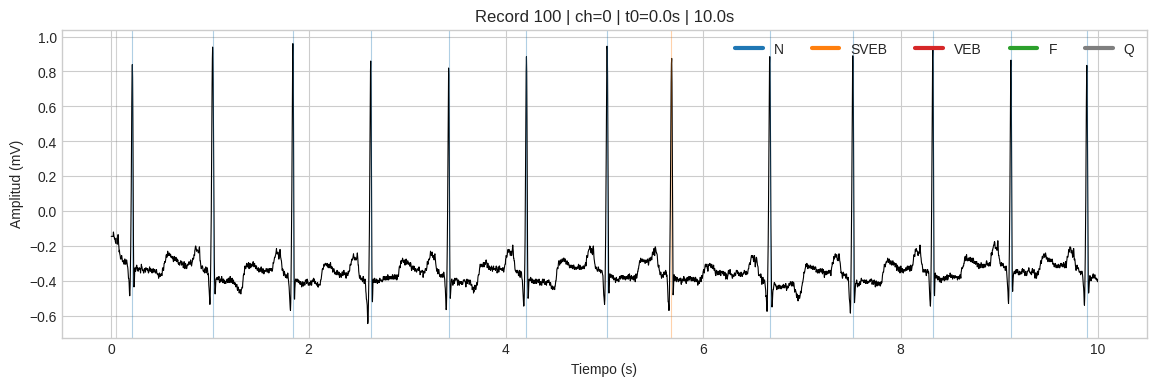

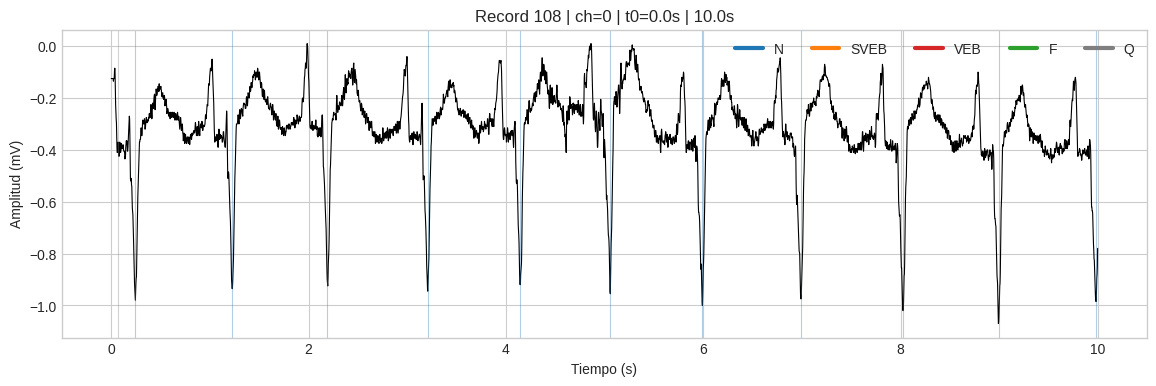

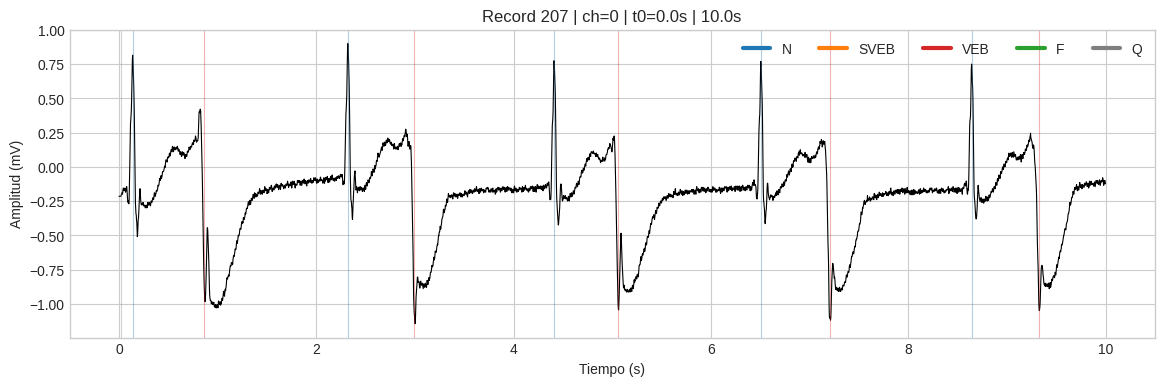

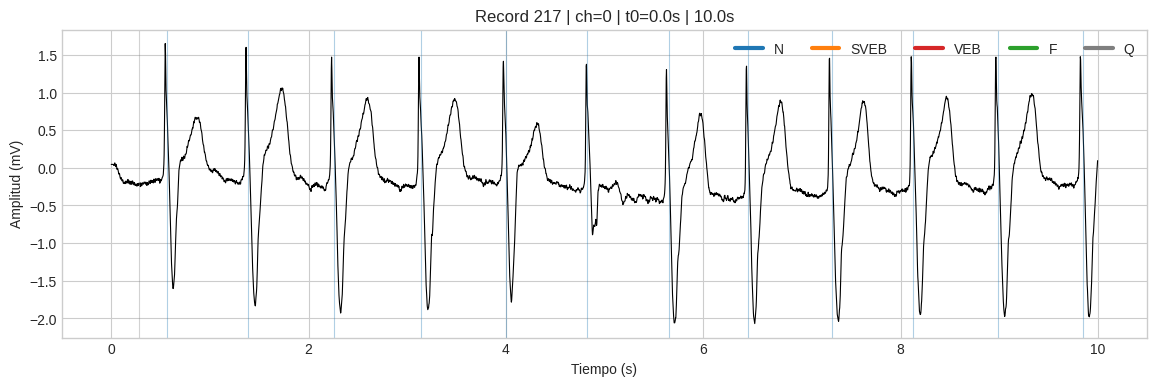

In [12]:
AAMI_COLOR = {
    "N": "#1f77b4",
    "SVEB": "#ff7f0e",
    "VEB": "#d62728",
    "F": "#2ca02c",
    "Q": "#7f7f7f",
}


def symbol_to_aami_name(sym: str) -> str:
    return AAMI_ID_TO_NAME[map_symbol_to_aami_5(sym)]


def plot_ecg_segment(
    record_id: str,
    t0: float,
    seconds: float = 10.0,
    channel: int = 0,
    show_annotations: bool = True,
) -> None:
    """Plot ECG crudo con anotaciones coloreadas por AAMI."""
    # Cargar todo el annotation vector (eficiente suficientemente para 30 min)
    ann = load_annotations(record_id)

    # Convertir ventana a samples
    sig_full, fs = load_record(record_id, sampfrom=None, sampto=None, channels=[channel])
    sig_full = sig_full[:, 0]

    s0 = sec_to_sample(t0, fs)
    s1 = s0 + sec_to_sample(seconds, fs)
    s0 = max(0, s0)
    s1 = min(len(sig_full), s1)

    x = np.arange(s0, s1) / fs
    y = sig_full[s0:s1]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(x, y, lw=0.8, color="black")

    if show_annotations:
        mask = (ann.sample >= s0) & (ann.sample < s1)
        a_samp = ann.sample[mask]
        a_sym = [ann.symbol[i] for i, m in enumerate(mask) if m]

        # marcar con líneas verticales
        for samp, sym in zip(a_samp, a_sym):
            cls = symbol_to_aami_name(sym)
            ax.axvline(samp / fs, color=AAMI_COLOR[cls], alpha=0.35, lw=0.8)

        # leyenda compacta
        handles = [
            plt.Line2D([0], [0], color=c, lw=3, label=k)
            for k, c in AAMI_COLOR.items()
        ]
        ax.legend(handles=handles, ncol=5, loc="upper right")

    ax.set_title(f"Record {record_id} | ch={channel} | t0={t0:.1f}s | {seconds:.1f}s")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud (mV)")
    plt.show()


# Ejemplos rápidos
for rid in ["100", "108", "207", "217"]:
    plot_ecg_segment(rid, t0=0.0, seconds=10.0, channel=0)


## 7) Segmentación por latidos (ventanas alrededor de R-peaks)

Construiremos latidos con el supuesto de la tesis:

- Ventana fija de **250 muestras** centrada en R-peak (aprox 0.694 s a 360 Hz).
- Convención: `pre = 125`, `post = 125` (simétrica) para EDA. Si más adelante decides asimétrica, se justifica clínicamente (p.ej. incluir más ST/T).

Se excluirán latidos **Q** para comparación N/SVEB/VEB, pero se contabilizan para métricas de calidad.

In [13]:
BEAT_LEN = 250
PRE = BEAT_LEN // 2
POST = BEAT_LEN - PRE


def extract_beats(
    record_id: str,
    channel: int = 0,
    max_beats: Optional[int] = None,
    include_q: bool = False,
) -> Tuple[np.ndarray, pd.DataFrame]:
    """Extrae beats centrados en R-peak (ann.sample).

    Returns:
        beats: (n_beats, BEAT_LEN)
        meta: DataFrame con record_id, idx, sample, symbol, aami_name
    """
    sig, fs = load_record(record_id, channels=[channel])
    sig = sig[:, 0]
    ann = load_annotations(record_id)

    beats = []
    meta_rows = []

    indices = np.arange(len(ann.sample))
    if max_beats is not None and max_beats < len(indices):
        indices = rng.choice(indices, size=max_beats, replace=False)
        indices = np.sort(indices)

    for i in indices:
        s = int(ann.sample[i])
        sym = str(ann.symbol[i])
        aami = symbol_to_aami_name(sym)

        if (not include_q) and (aami == "Q"):
            continue

        s0 = s - PRE
        s1 = s + POST
        if s0 < 0 or s1 > len(sig):
            continue

        beat = sig[s0:s1]
        if len(beat) != BEAT_LEN:
            continue

        beats.append(beat.astype(np.float32))
        meta_rows.append({
            "record_id": str(record_id),
            "ann_idx": int(i),
            "sample": int(s),
            "symbol": sym,
            "aami_name": aami,
        })

    beats = np.stack(beats, axis=0) if len(beats) else np.zeros((0, BEAT_LEN), dtype=np.float32)
    meta = pd.DataFrame(meta_rows)
    return beats, meta


# Ejemplo: extraer beats para registros foco
beats_108, meta_108 = extract_beats("108", channel=0, max_beats=2000, include_q=True)
beats_207, meta_207 = extract_beats("207", channel=0, max_beats=2000, include_q=True)
beats_217, meta_217 = extract_beats("217", channel=0, max_beats=2000, include_q=True)

print("108 beats:", beats_108.shape)
print(meta_108["aami_name"].value_counts())
print("207 beats:", beats_207.shape)
print(meta_207["aami_name"].value_counts())
print("217 beats:", beats_217.shape)
print(meta_217["aami_name"].value_counts())


108 beats: (1822, 250)
aami_name
N       1739
Q         60
VEB       17
SVEB       4
F          2
Name: count, dtype: int64
207 beats: (2000, 250)
aami_name
N       1292
Q        439
VEB      179
SVEB      90
Name: count, dtype: int64
217 beats: (1999, 250)
aami_name
N      1792
VEB     145
Q        62
Name: count, dtype: int64


## 8) Comparar morfología: N vs SVEB vs VEB (promedios, dispersión)

Compararemos latidos usando ventanas de 250 muestras centradas en R-peak.

Gráficos:

- Promedio ± desviación por clase.
- Spaghetti plots (múltiples latidos superpuestos) con alpha.

Esto ayuda a validar que la CNN 1D está viendo señales razonablemente separables (sin overinterpretar: SVEB puede ser sutil).

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/beats_mean_std_108.png


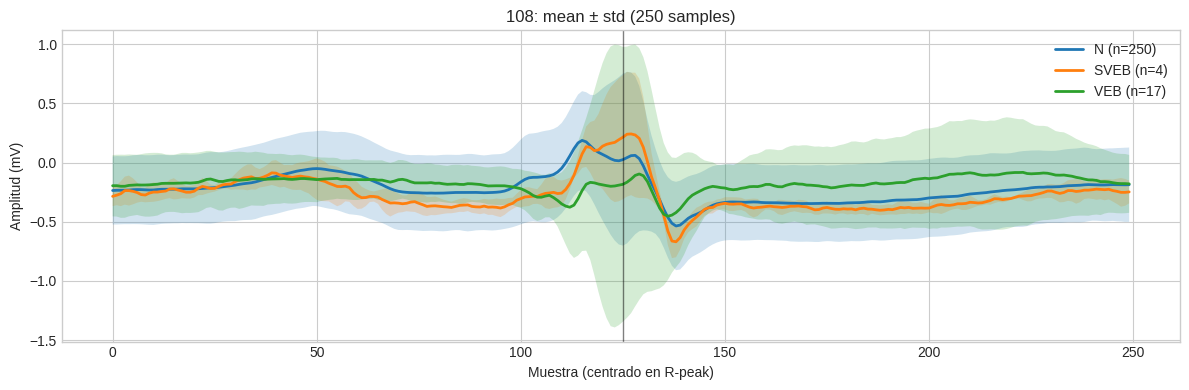

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/beats_spaghetti_108.png


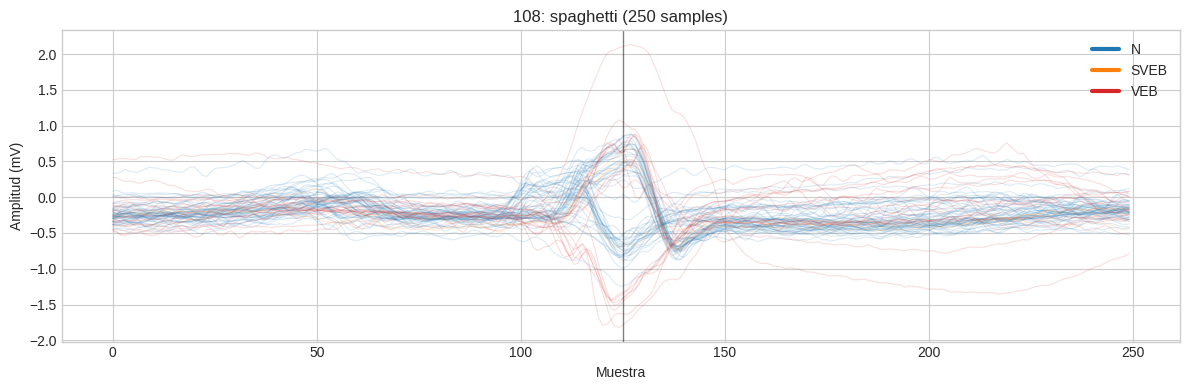

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/beats_mean_std_207.png


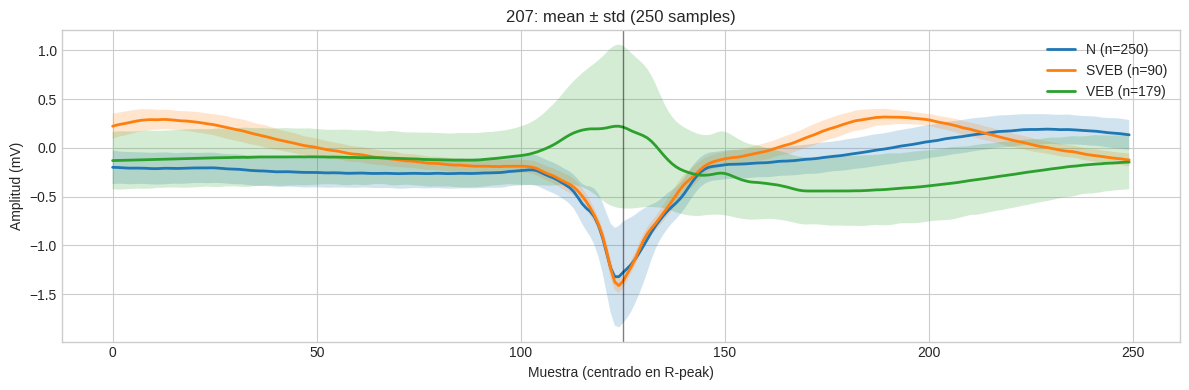

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/beats_spaghetti_207.png


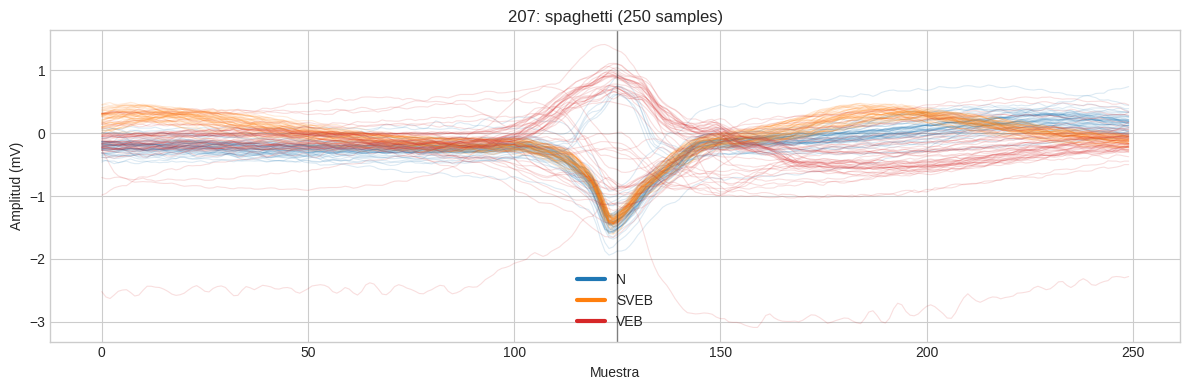

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/beats_mean_std_217.png


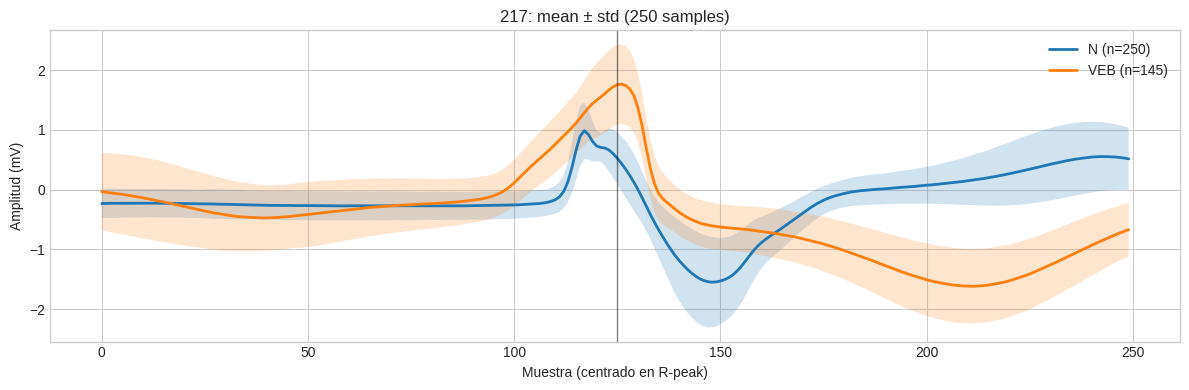

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/beats_spaghetti_217.png


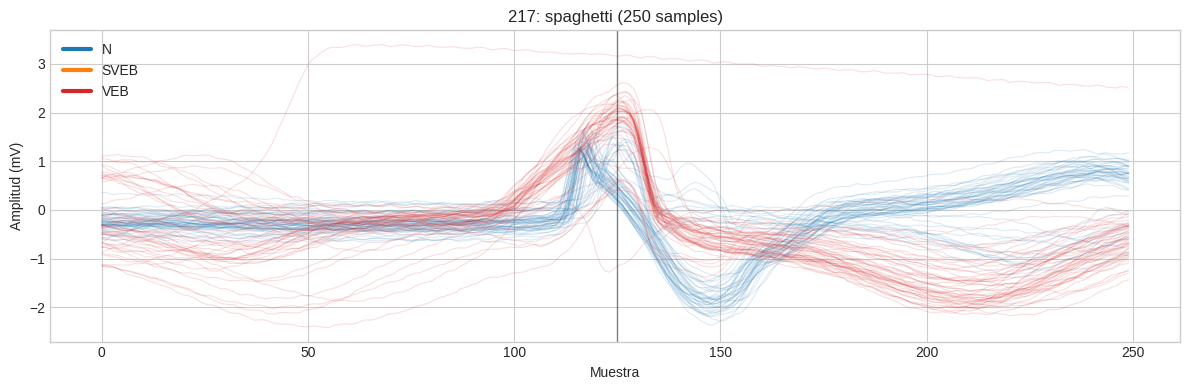

In [14]:
def balanced_sample_beats(beats: np.ndarray, meta: pd.DataFrame, per_class: int = 200) -> Dict[str, np.ndarray]:
    out: Dict[str, np.ndarray] = {}
    for cls in ["N", "SVEB", "VEB"]:
        idx = meta.index[meta["aami_name"] == cls].to_numpy()
        if len(idx) == 0:
            out[cls] = np.zeros((0, beats.shape[1]), dtype=np.float32)
            continue
        k = min(per_class, len(idx))
        chosen = rng.choice(idx, size=k, replace=False)
        out[cls] = beats[chosen]
    return out


def plot_mean_std(samples_by_class: Dict[str, np.ndarray], title: str) -> plt.Figure:
    x = np.arange(BEAT_LEN)
    fig, ax = plt.subplots(figsize=(12, 4))

    for cls in ["N", "SVEB", "VEB"]:
        X = samples_by_class[cls]
        if len(X) == 0:
            continue
        mu = X.mean(axis=0)
        sd = X.std(axis=0)
        ax.plot(x, mu, label=f"{cls} (n={len(X)})", lw=2)
        ax.fill_between(x, mu - sd, mu + sd, alpha=0.2)

    ax.axvline(PRE, color="k", lw=1, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("Muestra (centrado en R-peak)")
    ax.set_ylabel("Amplitud (mV)")
    ax.legend()
    return fig


def plot_spaghetti(samples_by_class: Dict[str, np.ndarray], title: str, n_each: int = 50) -> plt.Figure:
    x = np.arange(BEAT_LEN)
    fig, ax = plt.subplots(figsize=(12, 4))

    for cls, color in [("N", AAMI_COLOR["N"]), ("SVEB", AAMI_COLOR["SVEB"]), ("VEB", AAMI_COLOR["VEB"])]:
        X = samples_by_class[cls]
        if len(X) == 0:
            continue
        k = min(n_each, len(X))
        for i in range(k):
            ax.plot(x, X[i], color=color, alpha=0.15, lw=0.8)

    ax.axvline(PRE, color="k", lw=1, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("Muestra")
    ax.set_ylabel("Amplitud (mV)")

    handles = [
        plt.Line2D([0], [0], color=AAMI_COLOR["N"], lw=3, label="N"),
        plt.Line2D([0], [0], color=AAMI_COLOR["SVEB"], lw=3, label="SVEB"),
        plt.Line2D([0], [0], color=AAMI_COLOR["VEB"], lw=3, label="VEB"),
    ]
    ax.legend(handles=handles)
    return fig


for rid, beats, meta in [("108", beats_108, meta_108), ("207", beats_207, meta_207), ("217", beats_217, meta_217)]:
    samp = balanced_sample_beats(beats, meta, per_class=250)
    fig1 = plot_mean_std(samp, title=f"{rid}: mean ± std (250 samples)")
    save_fig(fig1, f"beats_mean_std_{rid}")
    plt.show()

    fig2 = plot_spaghetti(samp, title=f"{rid}: spaghetti (250 samples)")
    save_fig(fig2, f"beats_spaghetti_{rid}")
    plt.show()


## 9) Detección/diagnóstico de ruido (baseline wander, muscle, powerline)

Métricas simples por ventana (proxy):

- **Baseline wander**: varianza de la tendencia (media móvil / low-pass muy baja).
- **High-frequency (músculo)**: energía relativa en banda alta (40–100 Hz).
- **Powerline**: pico 50/60 Hz (dependiendo del país); estimamos potencia pico en 50 y 60.

Para mantenerlo ligero, estimaremos PSD con FFT (tipo Welch “manual” con promedios por segmentos) sin añadir dependencias nuevas.

> Esto es EDA; para el pipeline final de preprocessing puedes implementar filtros más formales en `src/data/preprocessing.py`.

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/psd_100_t0.png


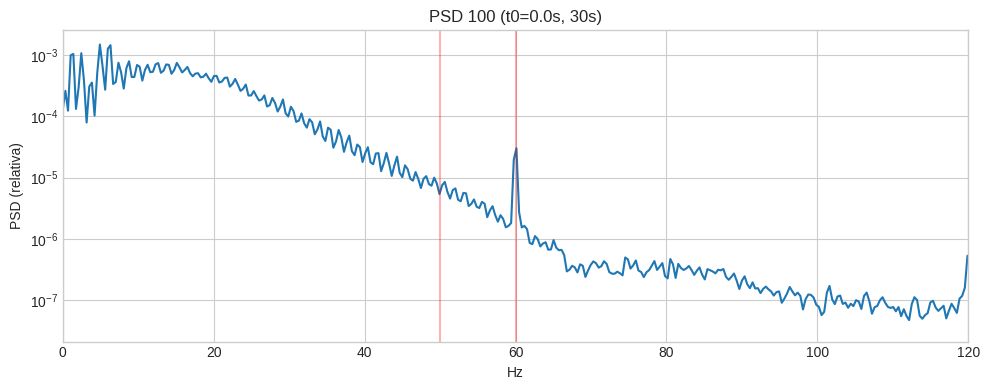

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/psd_108_t0.png


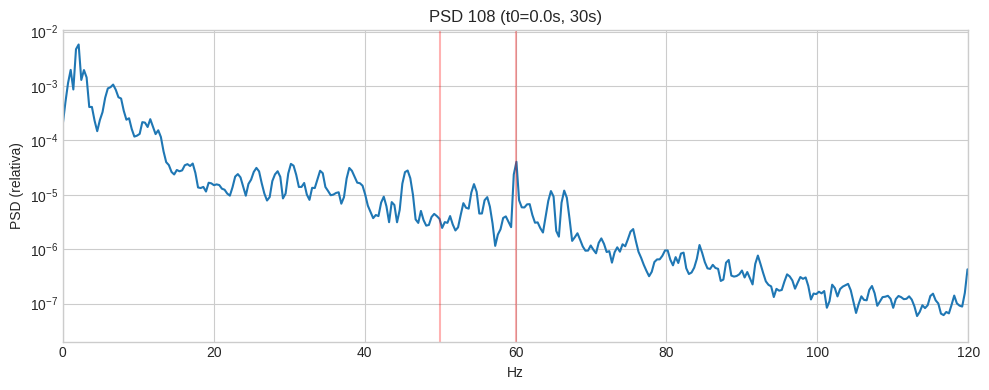

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/psd_207_t0.png


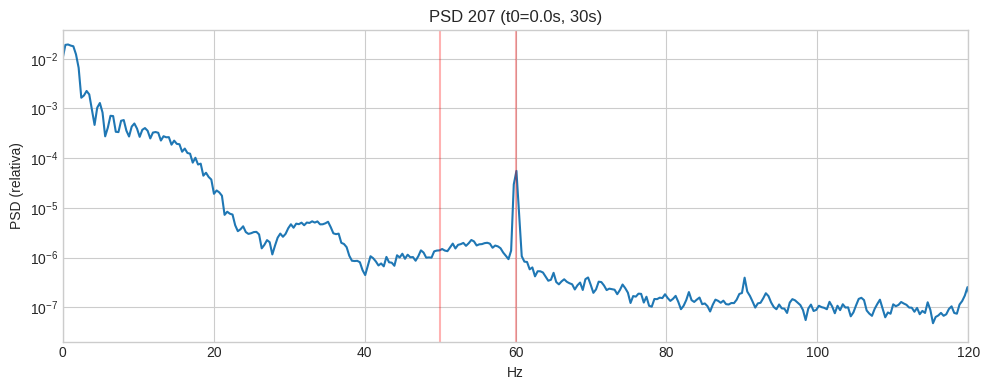

Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/figures/psd_217_t0.png


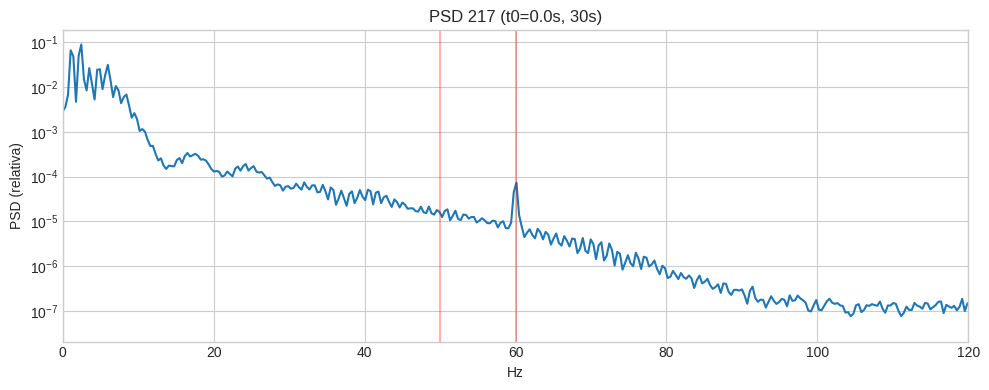

,record_id,t0,baseline_var,hf_ratio,peak50,peak60,p_0p5_40,p_40_100
0,100,0.0,0.001590,0.015045,0.000010,0.000030,0.014159,0.000213
1,108,0.0,0.002749,0.019451,0.000004,0.000040,0.010669,0.000208
2,207,0.0,0.018735,0.002167,0.000001,0.000056,0.031085,0.000067
3,217,0.0,0.013408,0.002591,0.000019,0.000073,0.183339,0.000475


Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/tables/noise_metrics_segments.csv


In [17]:
def psd_avg(x: np.ndarray, fs: int, nperseg: int = 1024, noverlap: int = 512) -> Tuple[np.ndarray, np.ndarray]:
    """Estimación PSD promedio (Welch simple) con Hann + FFT.

    Returns:
        f: frecuencias
        pxx: PSD promedio (unidades relativas)
    """
    x = np.asarray(x, dtype=float)
    if x.ndim != 1:
        raise ValueError("psd_avg espera 1D")

    step = nperseg - noverlap
    if step <= 0:
        raise ValueError("noverlap debe ser < nperseg")

    if len(x) < nperseg:
        # zero-pad
        pad = nperseg - len(x)
        x = np.pad(x, (0, pad))

    win = np.hanning(nperseg)
    scale = (win**2).sum()

    psds = []
    for start in range(0, len(x) - nperseg + 1, step):
        seg = x[start : start + nperseg]
        seg = seg - np.mean(seg)
        segw = seg * win
        X = np.fft.rfft(segw)
        P = (np.abs(X) ** 2) / (scale * fs)
        psds.append(P)

    pxx = np.mean(np.stack(psds, axis=0), axis=0)
    f = np.fft.rfftfreq(nperseg, d=1.0 / fs)
    return f, pxx


def band_power(f: np.ndarray, pxx: np.ndarray, fmin: float, fmax: float) -> float:
    m = (f >= fmin) & (f <= fmax)
    if not np.any(m):
        return 0.0
    # NumPy 2.x removió np.trapz; usar np.trapezoid
    return float(np.trapezoid(pxx[m], f[m]))


def peak_power_near(f: np.ndarray, pxx: np.ndarray, f0: float, tol: float = 1.0) -> float:
    m = (f >= (f0 - tol)) & (f <= (f0 + tol))
    if not np.any(m):
        return 0.0
    return float(np.max(pxx[m]))


def noise_metrics_for_segment(sig: np.ndarray, fs: int) -> Dict[str, float]:
    # Baseline wander proxy: var de media móvil (ventana 0.8s)
    w = int(round(0.8 * fs))
    w = max(3, w)
    kernel = np.ones(w) / w
    baseline = np.convolve(sig, kernel, mode="same")
    baseline_var = float(np.var(baseline))

    f, pxx = psd_avg(sig, fs=fs, nperseg=1024, noverlap=512)

    p_0p5_40 = band_power(f, pxx, 0.5, 40.0)
    p_40_100 = band_power(f, pxx, 40.0, 100.0)
    hf_ratio = float(p_40_100 / (p_0p5_40 + 1e-12))

    peak50 = peak_power_near(f, pxx, 50.0, tol=1.0)
    peak60 = peak_power_near(f, pxx, 60.0, tol=1.0)

    return {
        "baseline_var": baseline_var,
        "hf_ratio": hf_ratio,
        "peak50": peak50,
        "peak60": peak60,
        "p_0p5_40": float(p_0p5_40),
        "p_40_100": float(p_40_100),
    }


def plot_psd(sig: np.ndarray, fs: int, title: str) -> plt.Figure:
    f, pxx = psd_avg(sig, fs=fs)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(f, pxx + 1e-18)
    ax.set_xlim(0, 120)
    ax.set_xlabel("Hz")
    ax.set_ylabel("PSD (relativa)")
    ax.set_title(title)
    ax.axvline(50, color="r", alpha=0.3)
    ax.axvline(60, color="r", alpha=0.3)
    return fig


def get_raw_segment(record_id: str, t0: float, seconds: float, channel: int = 0) -> Tuple[np.ndarray, int]:
    sig, fs = load_record(record_id, channels=[channel])
    sig = sig[:, 0]
    s0 = sec_to_sample(t0, fs)
    s1 = s0 + sec_to_sample(seconds, fs)
    s0 = max(0, s0)
    s1 = min(len(sig), s1)
    return sig[s0:s1], fs


# Comparar métricas de ruido de segmentos para registros foco vs referencia
segments = [
    ("100", 0.0),
    ("108", 0.0),
    ("207", 0.0),
    ("217", 0.0),
]

rows = []
for rid, t0 in segments:
    seg, fs = get_raw_segment(rid, t0=t0, seconds=30.0, channel=0)
    met = noise_metrics_for_segment(seg, fs)
    rows.append({"record_id": rid, "t0": t0, **met})

    fig = plot_psd(seg, fs, title=f"PSD {rid} (t0={t0}s, 30s)")
    save_fig(fig, f"psd_{rid}_t{int(t0)}")
    plt.show()

noise_df = pd.DataFrame(rows)
display(noise_df)
save_table(noise_df, "noise_metrics_segments")

## 10) Métricas de calidad por registro (SNR proxy, tasa de artefactos, % no-clasificables)

Construimos un ranking por registro usando:

- `%Q` (no-clasificable) desde el índice/tabla AAMI.
- Proxy de ruido desde 2–3 segmentos por registro (baseline_var, hf_ratio, peak50/peak60).

Esto permite priorizar decisiones de preprocessing y también detectar si 108/207/217 destacan por calidad/dificultad.

In [18]:
def quality_metrics_for_record(record_id: str, n_segments: int = 3, seconds: float = 20.0, channel: int = 0) -> Dict[str, float]:
    # Cargar señal completa para muestrear posiciones
    sig, fs = load_record(record_id, channels=[channel])
    sig = sig[:, 0]

    # Evitar extremos
    max_start = max(1, len(sig) - sec_to_sample(seconds, fs) - 1)
    if max_start <= 1:
        return {"baseline_var": np.nan, "hf_ratio": np.nan, "peak50": np.nan, "peak60": np.nan}

    starts = rng.integers(low=0, high=max_start, size=n_segments)

    mets = []
    for s0 in starts:
        seg = sig[s0 : s0 + sec_to_sample(seconds, fs)]
        mets.append(noise_metrics_for_segment(seg, fs))

    # Promedio
    out = {k: float(np.mean([m[k] for m in mets])) for k in mets[0].keys()}
    return out


# Para EDA rápido: evaluamos sólo algunos registros (todos puede tardar)
record_subset = df_index["record_id"].tolist()

rows = []
for rid in record_subset:
    q_pct = float(df_aami_pct.loc[rid, "Q"]) if rid in df_aami_pct.index else np.nan
    mets = quality_metrics_for_record(rid, n_segments=2, seconds=15.0, channel=0)
    rows.append({"record_id": rid, "pct_Q": q_pct, **mets})

quality_df = pd.DataFrame(rows)

# Ranking simple: combinar %Q + hf_ratio + peak power
quality_df["score_bad"] = (
    quality_df["pct_Q"].fillna(0.0)
    + 10.0 * quality_df["hf_ratio"].fillna(0.0)
    + 1e3 * np.maximum(quality_df["peak50"].fillna(0.0), quality_df["peak60"].fillna(0.0))
)

quality_rank = quality_df.sort_values("score_bad", ascending=False)

display(quality_rank.head(15))
save_table(quality_rank, "quality_rank_proxy")


,record_id,pct_Q,baseline_var,hf_ratio,peak50,peak60,p_0p5_40,p_40_100,score_bad
28,207,22.012579,0.008462,0.001269,0.000003,5.083239e-05,0.075614,0.000092,22.076103
44,231,21.879662,0.003179,0.004129,0.000003,9.714211e-07,0.027688,0.000117,21.923868
43,230,8.515815,0.001390,0.001108,0.000002,5.388559e-07,0.050576,0.000058,8.528705
23,200,6.840974,0.010620,0.007103,0.000034,2.646229e-05,0.073880,0.000536,6.945690
37,219,6.833910,0.134196,0.001331,0.000004,1.479161e-06,0.085459,0.000115,6.851301
40,222,5.732726,0.007775,0.027839,0.000005,6.934182e-05,0.007286,0.000203,6.080457
18,119,5.109838,0.077561,0.001903,0.000008,2.339463e-06,0.111583,0.000167,5.137362
4,104,4.327131,0.001303,0.033308,0.000035,5.240089e-05,0.022477,0.000744,4.712615
5,105,4.607952,0.002138,0.001203,0.000002,3.430759e-05,0.048864,0.000059,4.654295
26,203,4.247104,0.012483,0.009953,0.000028,1.084148e-04,0.053478,0.000495,4.455053


Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/tables/quality_rank_proxy.csv


## 11) Análisis focal: registros problemáticos 108, 207, 217 (plots + tablas)

Para cada registro:

1) Tabla de conteos por símbolo (top-N) y por AAMI.
2) 2–3 segmentos crudos (ventanas distintas) para inspección visual.
3) Ejemplos de beats N/SVEB/VEB (si existen) y comparación con registro normal (100).
4) PSD y métricas de ruido.

Esto produce evidencia concreta para justificar (en estilo IEEE) decisiones de preprocessing y criterios de exclusión/ponderación.

Top símbolos por registro (head):


,record_id,symbol,count
0,100,N,2239
1,100,A,33
2,100,+,1
3,100,V,1
4,108,N,1739
5,108,~,41
6,108,V,17
7,108,x,11
8,108,|,8
9,108,A,4


AAMI por registro:


,record_id,aami_name,count
0,100,N,2239
1,100,SVEB,33
2,100,Q,1
3,100,VEB,1
4,108,N,1740
5,108,Q,61
6,108,VEB,17
7,108,SVEB,4
8,108,F,2
9,207,N,1543


Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/tables/focus_symbol_tables.csv
Saved: /home/clau/Desktop/Tesis/ecg-arrhythmia-thesis/ecg-arrhythmia-thesis/reports/eda/tables/focus_aami_tables.csv


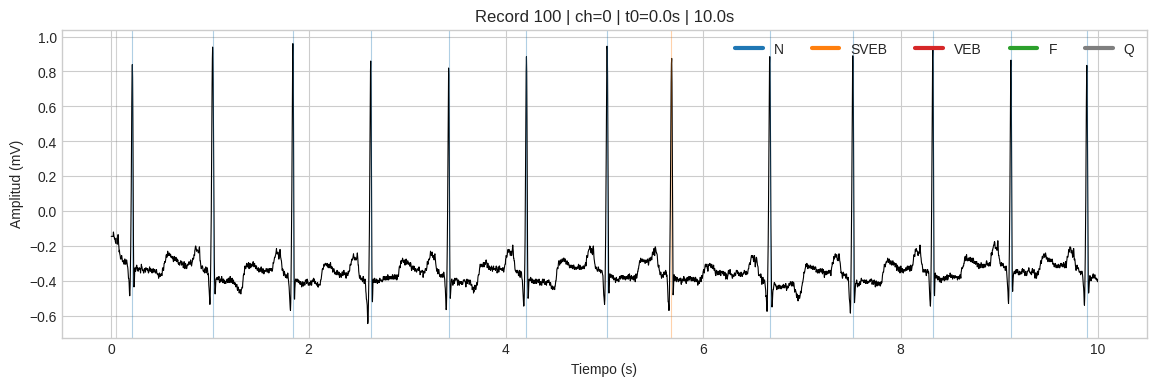

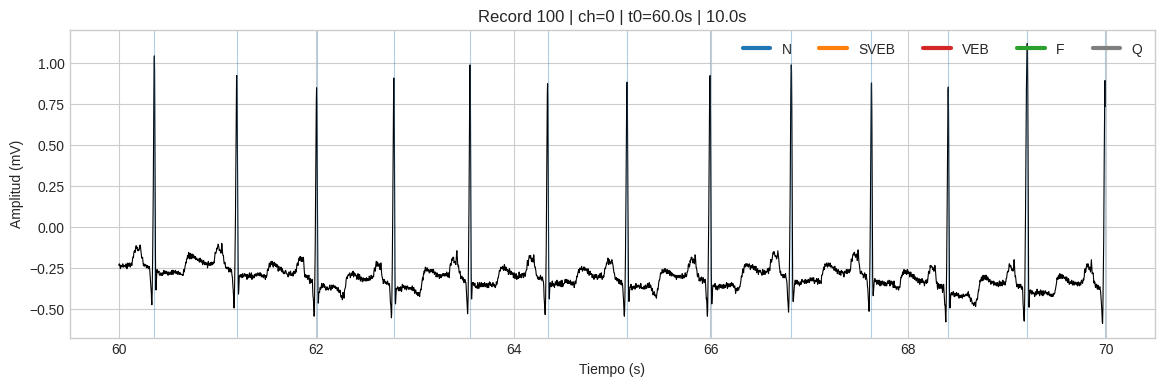

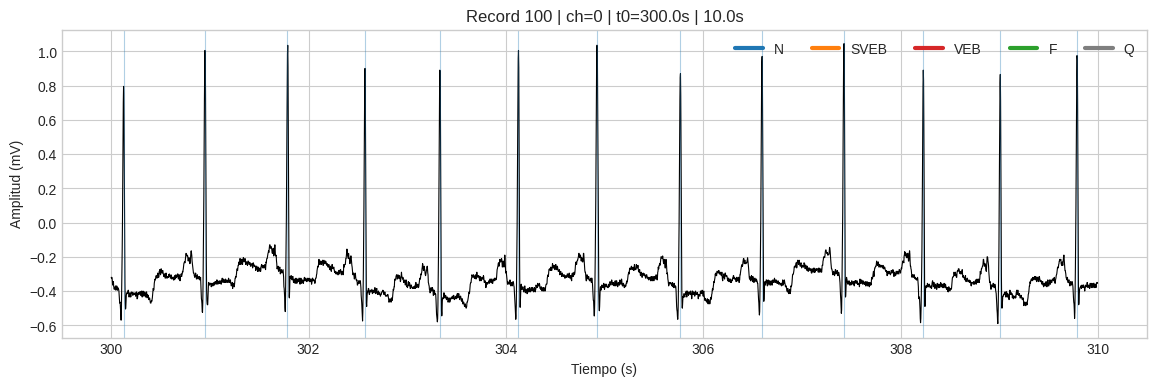

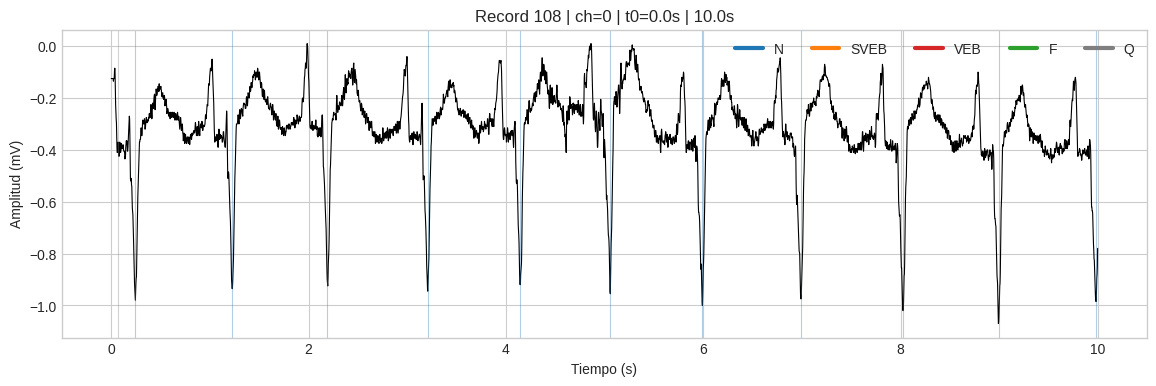

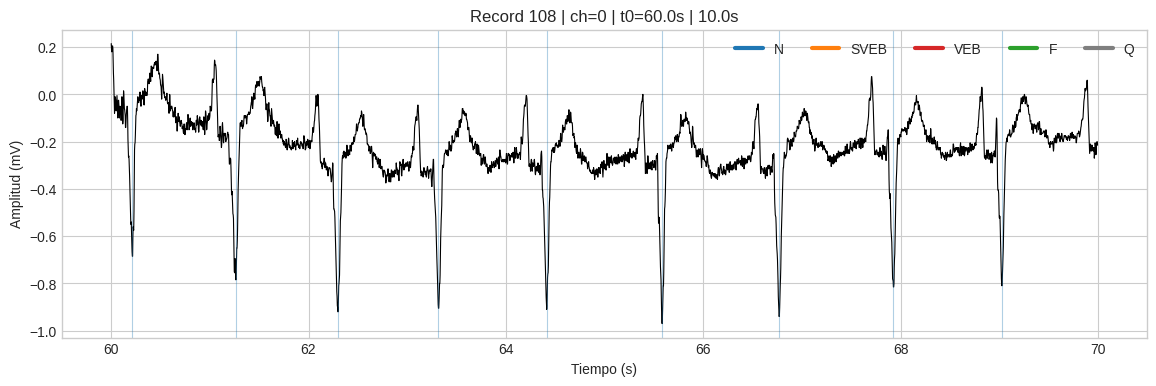

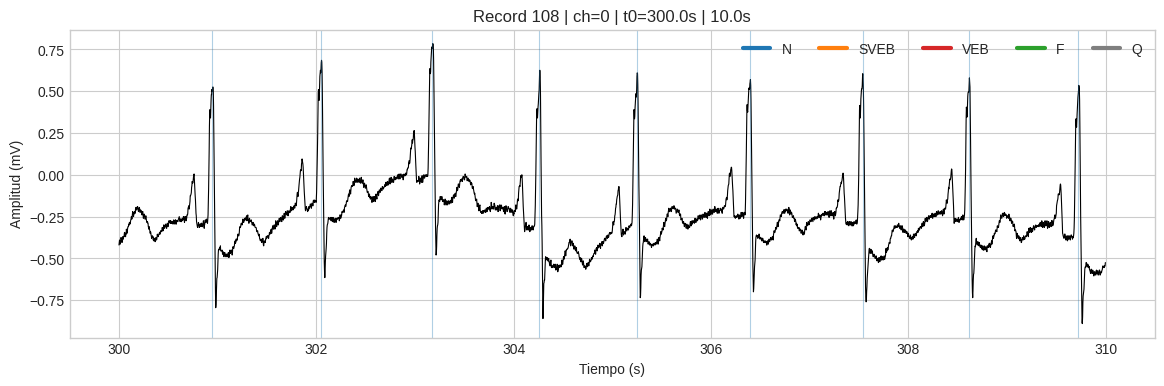

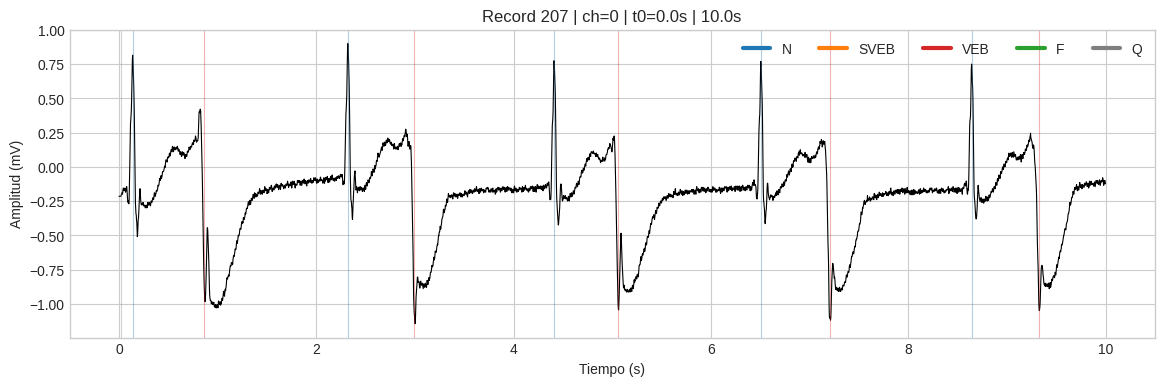

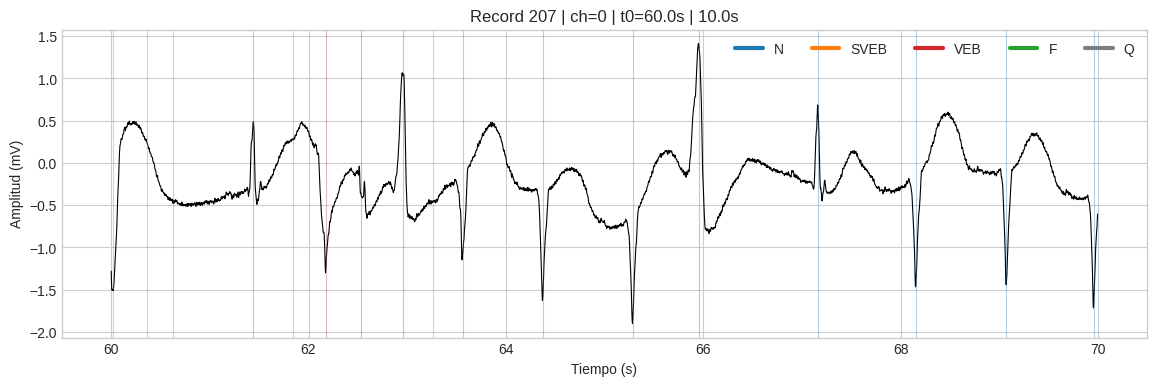

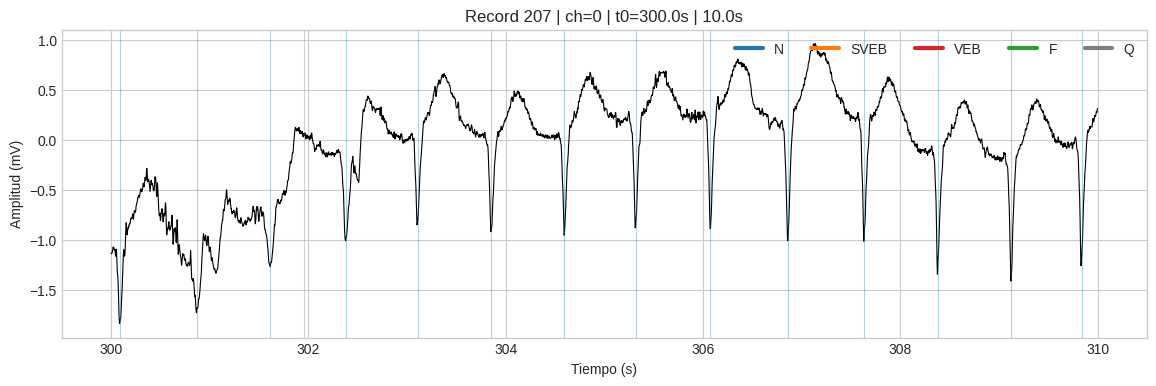

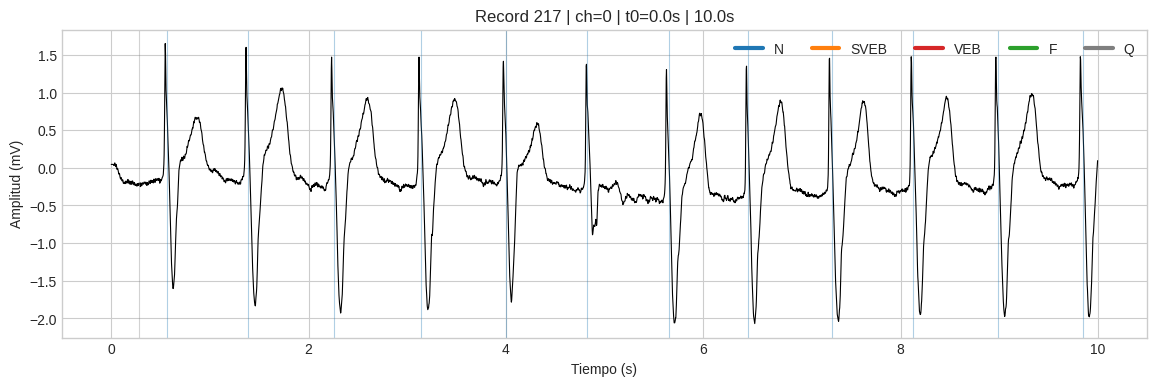

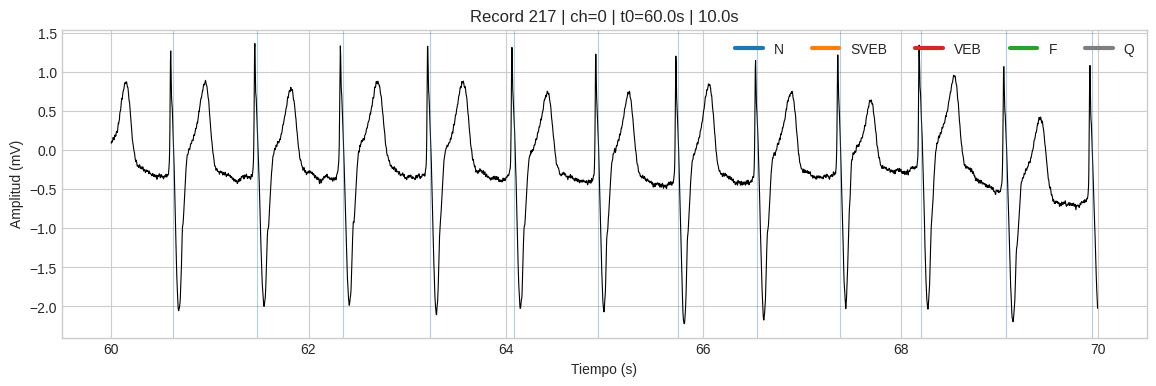

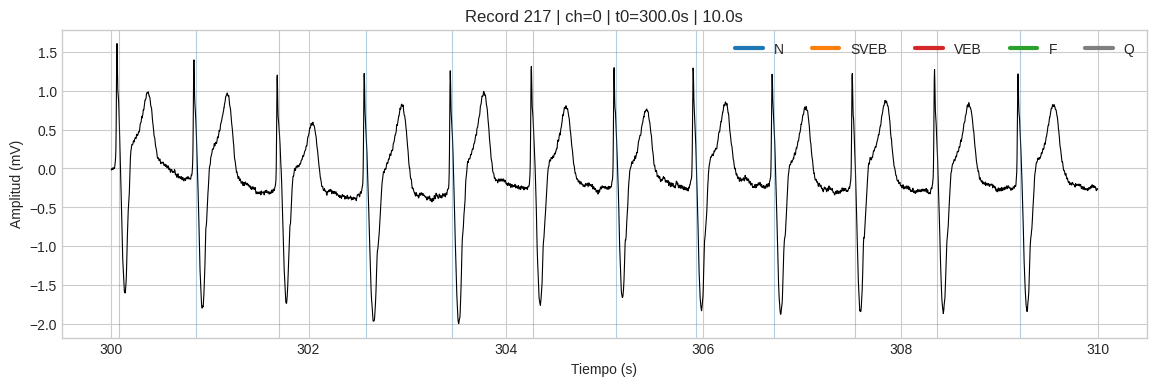

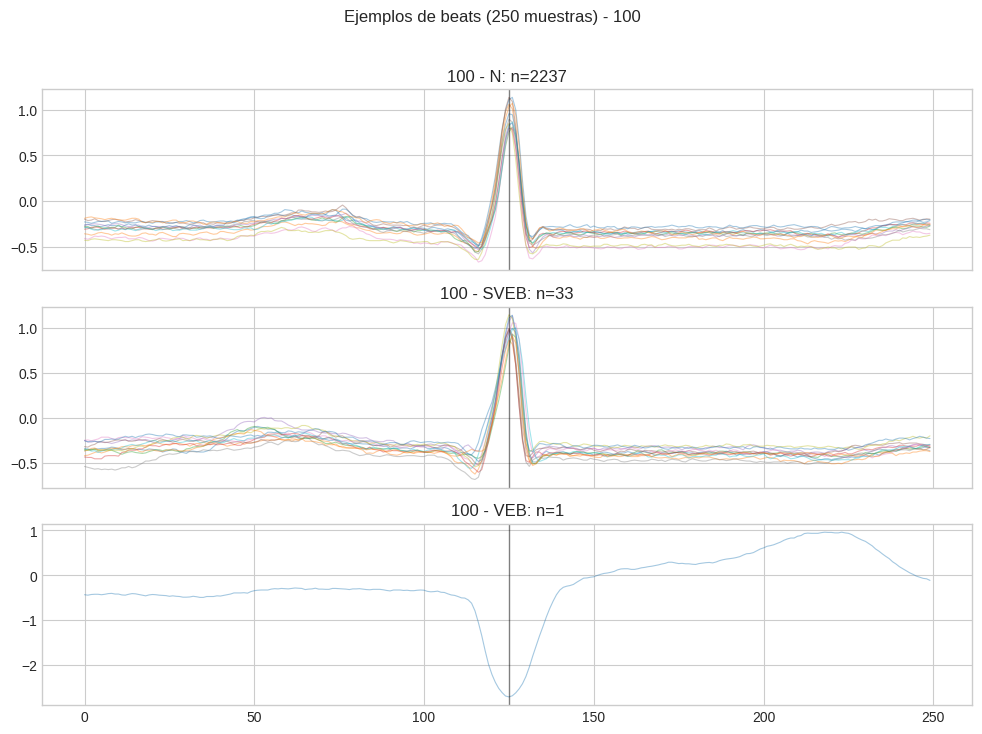

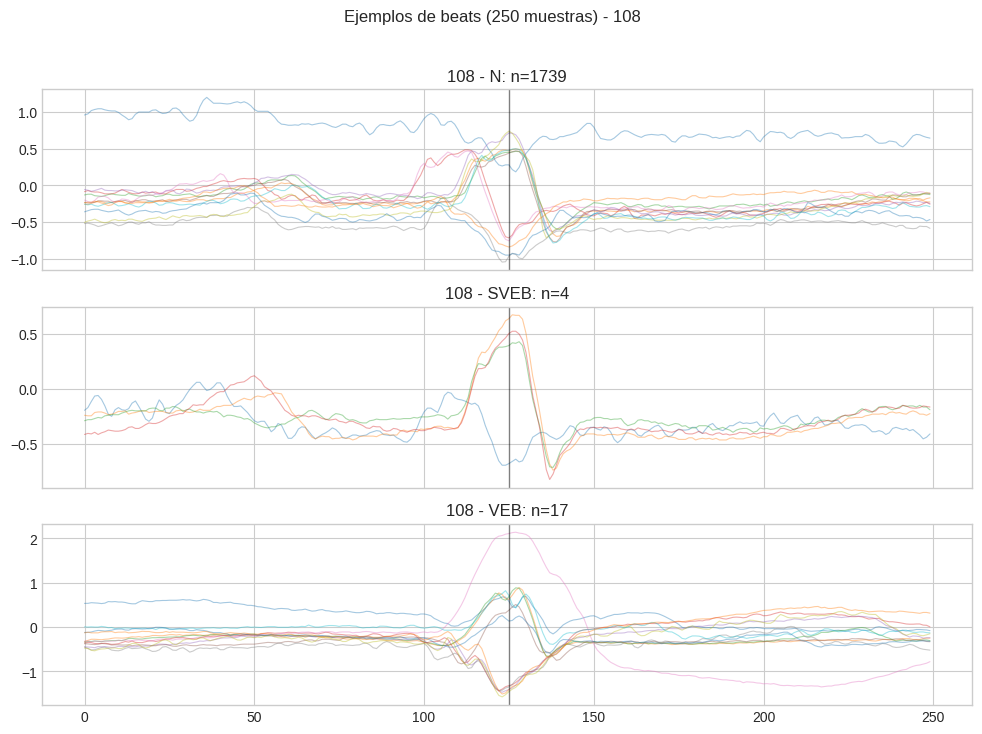

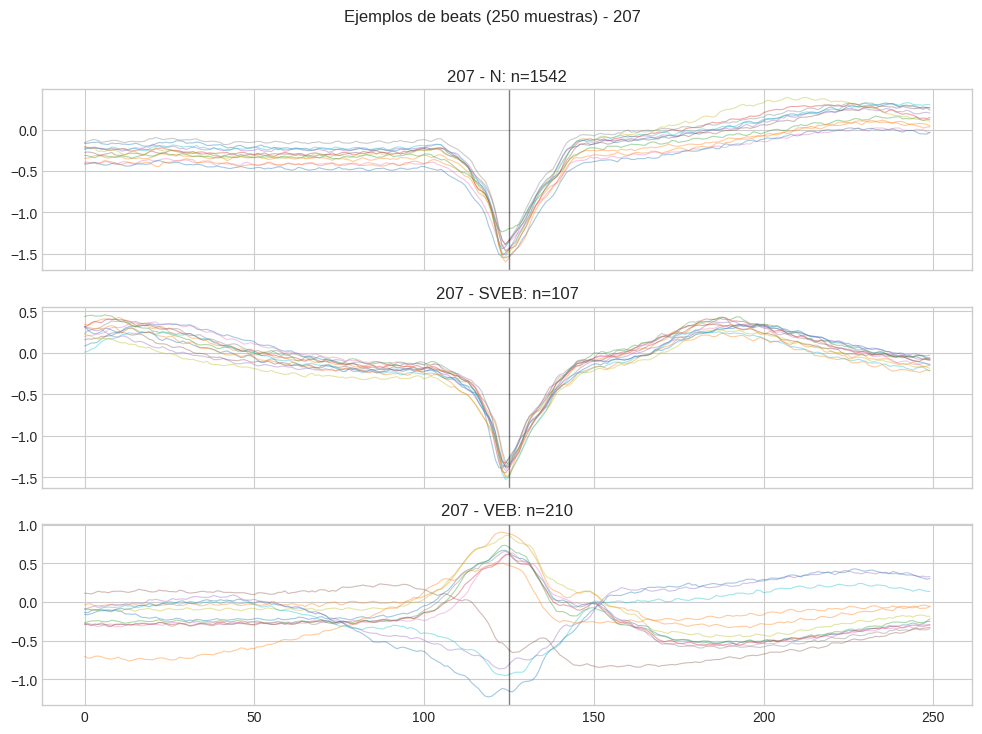

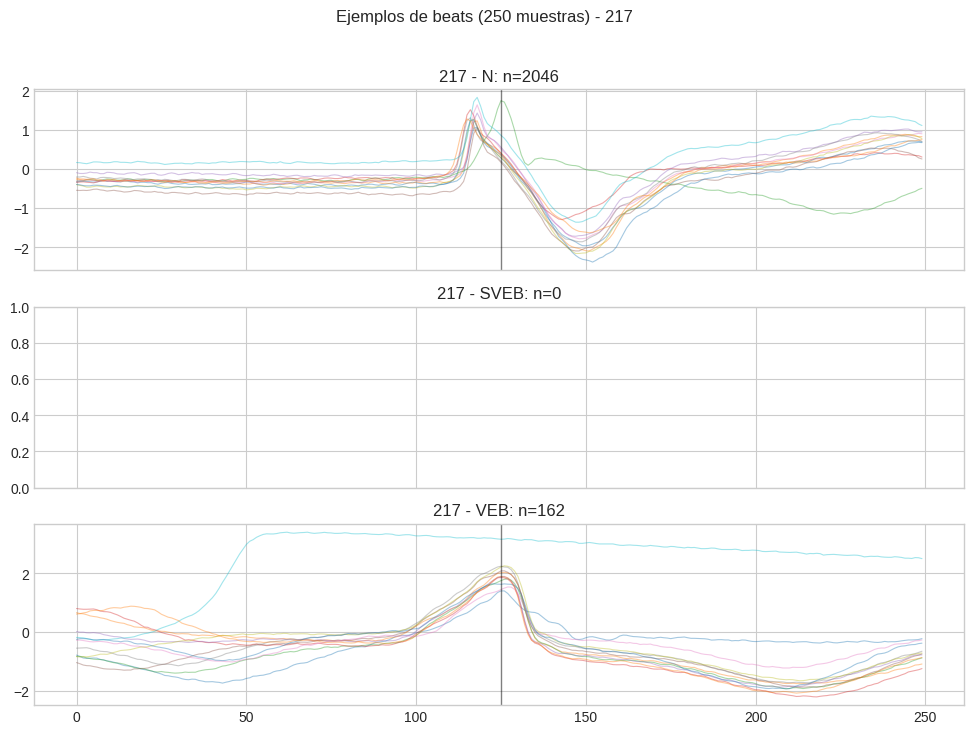

In [19]:
FOCUS = ["108", "207", "217"]
REFERENCE = "100"


def symbol_table_for_record(record_id: str) -> pd.DataFrame:
    d = parse_symbol_counts(df_index.loc[df_index["record_id"] == record_id, "symbol_counts_json"].iloc[0])
    df = pd.DataFrame([{ "symbol": k, "count": v } for k, v in d.items()]).sort_values("count", ascending=False)
    df["record_id"] = record_id
    return df[["record_id", "symbol", "count"]]


def aami_table_for_record(record_id: str) -> pd.DataFrame:
    df = df_symbols_long.loc[df_symbols_long["record_id"] == record_id].copy()
    out = (
        df.groupby("aami_name", as_index=False)["count"].sum()
        .sort_values("count", ascending=False)
    )
    out["record_id"] = record_id
    return out[["record_id", "aami_name", "count"]]


# Tablas de conteo
sym_tables = pd.concat([symbol_table_for_record(r) for r in [REFERENCE] + FOCUS], ignore_index=True)
aami_tables = pd.concat([aami_table_for_record(r) for r in [REFERENCE] + FOCUS], ignore_index=True)

print("Top símbolos por registro (head):")
display(sym_tables.groupby("record_id").head(12))
print("AAMI por registro:")
display(aami_tables)

save_table(sym_tables, "focus_symbol_tables")
save_table(aami_tables, "focus_aami_tables")


# Segmentos crudos representativos
# (puedes ajustar manualmente t0 si quieres ver regiones específicas)
segment_windows = [0.0, 60.0, 300.0]  # segundos

for rid in [REFERENCE] + FOCUS:
    for t0 in segment_windows:
        plot_ecg_segment(rid, t0=t0, seconds=10.0, channel=0)


# Ejemplos de beats de cada clase

def plot_example_beats(record_id: str, beats: np.ndarray, meta: pd.DataFrame, n_each: int = 12) -> None:
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, cls in zip(axes, ["N", "SVEB", "VEB"]):
        idx = meta.index[meta["aami_name"] == cls].to_numpy()
        if len(idx) == 0:
            ax.set_title(f"{record_id} - {cls}: n=0")
            continue
        k = min(n_each, len(idx))
        chosen = rng.choice(idx, size=k, replace=False)
        for j in chosen:
            ax.plot(beats[j], alpha=0.4, lw=0.8)
        ax.axvline(PRE, color="k", lw=1, alpha=0.5)
        ax.set_title(f"{record_id} - {cls}: n={len(idx)}")
    plt.suptitle(f"Ejemplos de beats (250 muestras) - {record_id}")
    plt.show()


# Re-extraer con include_q=False para asegurar beats alineados a N/SVEB/VEB
beats_ref, meta_ref = extract_beats(REFERENCE, channel=0, max_beats=2500, include_q=False)
plot_example_beats(REFERENCE, beats_ref, meta_ref)

for rid in FOCUS:
    b, m = extract_beats(rid, channel=0, max_beats=2500, include_q=False)
    plot_example_beats(rid, b, m)


## 12) Exportar figuras/tablas a `reports/` y helpers reproducibles

Este notebook ya guarda:

- Figuras en `reports/eda/figures/` (PNG/SVG).
- Tablas en `reports/eda/tables/` (CSV).

Incluimos una celda final de checks rápidos para:

- Parsing JSON.
- Mapeo AAMI.
- Carga WFDB.

Esto ayuda a que el notebook sea “ejecutable” de forma reproducible (útil también para CI ligero o para detectar corrupción de datos).

In [20]:
# Sanity checks

# JSON parse
s = df_index.loc[df_index["record_id"] == "108", "symbol_counts_json"].iloc[0]
d = parse_symbol_counts(s)
assert isinstance(d, dict) and len(d) > 0

# Mapping AAMI
assert symbol_to_aami_name("N") == "N"
assert symbol_to_aami_name("A") in {"SVEB", "Q"}  # depende si se importó mapping del proyecto
assert symbol_to_aami_name("V") in {"VEB", "Q"}
assert symbol_to_aami_name("F") in {"F", "Q"}

# WFDB load
sig, fs = load_record("100", sampfrom=0, sampto=3600, channels=[0])
ann = load_annotations("100")
assert fs == 360
assert sig.ndim == 2 and sig.shape[0] == 3600
assert len(ann.sample) > 0

print("All sanity checks passed.")


All sanity checks passed.
